In [1]:
# ============================================================
# Section 1. Function definitions
# Transfer matrix for disordered QWZ model
# ============================================================

import os
import csv
import time
import shutil
import numpy as np
import pandas as pd
import scipy.linalg as la
import matplotlib.pyplot as plt


# -----------------------------
# Pauli matrices
# -----------------------------

sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
id2 = np.eye(2, dtype=complex)


# -----------------------------
# QWZ hopping blocks
# -----------------------------

def qwz_hopping_blocks(A=1.5, t=1.0):
    """
    QWZ convention:

        H(k) = -A sin(kx) sx - A sin(ky) sy
             + [u + t cos(kx) + t cos(ky)] sz

    Real-space hopping:
        H_{r,r+x} = Tx
        H_{r,r+y} = Ty
    """
    Tx = 0.5 * t * sz + 0.5j * A * sx
    Ty = 0.5 * t * sz + 0.5j * A * sy
    return Tx, Ty


def build_slice_hamiltonian(
    M,
    impurity_mask,
    u=-2.05,
    A=1.5,
    t=1.0,
    h=-1.0,
):
    """
    Build H_x inside one transverse slice.

    Slice width: M
    Orbitals per site: 2
    Slice dimension: 2M

    impurity_mask[y] = True means site (x,y) has impurity.
    """
    dim = 2 * M
    Hx = np.zeros((dim, dim), dtype=complex)

    _, Ty = qwz_hopping_blocks(A=A, t=t)

    for y in range(M):
        sl = slice(2*y, 2*y + 2)

        onsite = u * sz
        if impurity_mask[y]:
            onsite = onsite - h * sz

        Hx[sl, sl] += onsite

        # periodic y hopping
        yp = (y + 1) % M
        slp = slice(2*yp, 2*yp + 2)

        Hx[sl, slp] += Ty
        Hx[slp, sl] += Ty.conj().T

    return Hx


def random_impurity_mask(M, nd=0.03, rng=None):
    """
    Bernoulli disorder for one slice.
    Each transverse site has impurity probability nd.
    """
    if rng is None:
        rng = np.random.default_rng()

    return rng.random(M) < nd


def build_transfer_matrix_for_slice(
    M,
    impurity_mask,
    E=0.0,
    u=-2.05,
    A=1.5,
    t=1.0,
    h=-1.0,
):
    """
    Build transfer matrix T_x such that:

        [psi_{x+1}]   [Vx^{-1}(E-Hx), -Vx^{-1}Vx^dag] [psi_x    ]
        [psi_x    ] = [I,               0             ] [psi_{x-1}]
    """
    Tx, _ = qwz_hopping_blocks(A=A, t=t)
    Hx = build_slice_hamiltonian(
        M=M,
        impurity_mask=impurity_mask,
        u=u,
        A=A,
        t=t,
        h=h,
    )

    dim = 2 * M
    I = np.eye(dim, dtype=complex)

    Vx = np.kron(np.eye(M, dtype=complex), Tx)

    Ablock = la.solve(Vx, E * I - Hx)
    Bblock = -la.solve(Vx, Vx.conj().T)

    upper = np.hstack([Ablock, Bblock])
    lower = np.hstack([I, np.zeros_like(I)])

    return np.vstack([upper, lower])


# -----------------------------
# Lyapunov exponents
# -----------------------------

def lyapunov_exponents_qr(
    M,
    h,
    n_slices=100000,
    E=0.0,
    u=-2.05,
    A=1.5,
    t=1.0,
    nd=0.03,
    seed=12345,
    qr_interval=1,
    verbose=False,
):
    """
    Compute Lyapunov exponents by QR stabilization.

    Output:
        gamma_min_pos
        xi_M = 1 / gamma_min_pos
        Lambda = xi_M / M
    """
    rng = np.random.default_rng(seed)

    dim_slice = 2 * M
    dim_T = 2 * dim_slice

    Q = np.eye(dim_T, dtype=complex)
    log_diag_accum = np.zeros(dim_T, dtype=float)

    n_qr = 0
    t0 = time.time()

    for x in range(n_slices):
        impurity_mask = random_impurity_mask(M, nd=nd, rng=rng)

        Tmat = build_transfer_matrix_for_slice(
            M=M,
            impurity_mask=impurity_mask,
            E=E,
            u=u,
            A=A,
            t=t,
            h=h,
        )

        Q = Tmat @ Q

        if (x + 1) % qr_interval == 0:
            Q, R = la.qr(Q, mode="economic")

            diag_R = np.abs(np.diag(R))
            diag_R = np.maximum(diag_R, 1e-300)

            log_diag_accum += np.log(diag_R)
            n_qr += 1

        if verbose and (x + 1) % max(1, n_slices // 5) == 0:
            print(f"  slice {x+1}/{n_slices}")

    total_length = n_qr * qr_interval
    gammas = np.sort(np.real(log_diag_accum / total_length))

    positive = gammas[gammas > 1e-10]

    if len(positive) == 0:
        gamma_min_pos = np.nan
        xi_M = np.inf
        Lambda = np.inf
    else:
        gamma_min_pos = positive[0]
        xi_M = 1.0 / gamma_min_pos
        Lambda = xi_M / M

    runtime = time.time() - t0

    return {
        "M": M,
        "h": h,
        "n_slices": n_slices,
        "seed": seed,
        "gamma_min_pos": gamma_min_pos,
        "xi_M": xi_M,
        "Lambda": Lambda,
        "gammas": gammas,
        "runtime_sec": runtime,
    }


# -----------------------------
# Safe CSV helpers
# -----------------------------

def safe_load_done_keys(out_csv):
    """
    Read existing raw CSV to enable checkpoint restart.

    If the CSV is corrupted or incompatible, rename it to backup
    and start fresh.
    """
    done = set()

    if not os.path.exists(out_csv):
        return done

    try:
        old = pd.read_csv(out_csv)

        required_cols = {"M", "h", "seed"}
        if not required_cols.issubset(set(old.columns)):
            backup_name = out_csv.replace(".csv", "_incompatible_backup.csv")
            shutil.move(out_csv, backup_name)
            print(f"Existing CSV has incompatible columns.")
            print(f"Moved it to: {backup_name}")
            return done

        for _, r in old.iterrows():
            done.add((int(r["M"]), float(r["h"]), int(r["seed"])))

        print(f"Loaded existing checkpoint: {out_csv}")
        print(f"Existing completed runs: {len(done)}")

        return done

    except Exception as e:
        backup_name = out_csv.replace(".csv", "_corrupted_backup.csv")
        shutil.move(out_csv, backup_name)
        print(f"Could not read existing CSV because: {repr(e)}")
        print(f"Moved it to: {backup_name}")
        return done


def append_row_to_csv(row, out_csv, fields):
    """
    Append one row to CSV. Create header if file does not exist.
    """
    file_exists = os.path.exists(out_csv)

    with open(out_csv, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fields)

        if not file_exists:
            writer.writeheader()

        writer.writerow(row)


def summarize_raw(raw, summary_csv=None):
    """
    Summarize raw transfer-matrix data.
    """
    summary = raw.groupby(["M", "h"], as_index=False).agg(
        n=("Lambda", "count"),
        mean_gamma=("gamma_min_pos", "mean"),
        std_gamma=("gamma_min_pos", "std"),
        mean_xi=("xi_M", "mean"),
        std_xi=("xi_M", "std"),
        mean_Lambda=("Lambda", "mean"),
        std_Lambda=("Lambda", "std"),
        median_Lambda=("Lambda", "median"),
        min_Lambda=("Lambda", "min"),
        max_Lambda=("Lambda", "max"),
        mean_runtime_sec=("runtime_sec", "mean"),
    )

    if summary_csv is not None:
        summary.to_csv(summary_csv, index=False)
        print("Saved summary:", summary_csv)

    return summary


# -----------------------------
# Main scan driver
# -----------------------------

def transfer_scan(
    M_list,
    h_values,
    n_slices=100000,
    n_seeds=4,
    seed0=202607200,
    out_csv="tm_scan_raw.csv",
    model_params=None,
):
    """
    Run transfer-matrix scan with checkpointing.

    Saves one row per (M,h,seed).
    """
    out_dir = os.path.dirname(out_csv)
    if out_dir != "":
        os.makedirs(out_dir, exist_ok=True)

    if model_params is None:
        model_params = {
            "u": -2.05,
            "A": 1.5,
            "t": 1.0,
            "nd": 0.03,
            "E": 0.0,
        }

    fields = [
        "M", "h", "n_slices", "seed", "seed_index",
        "u", "A", "t", "nd", "E",
        "gamma_min_pos", "xi_M", "Lambda", "runtime_sec",
    ]

    done = safe_load_done_keys(out_csv)

    for M in M_list:
        for ih, h in enumerate(h_values):
            for iseed in range(n_seeds):
                seed = int(seed0 + 1000000*M + 1000*ih + iseed)
                key = (int(M), float(h), int(seed))

                if key in done:
                    print(f"[skip] M={M}, h={h:.6f}, seed={seed}")
                    continue

                print("\n" + "="*80)
                print(
                    f"[run] M={M}, h={h:.6f}, "
                    f"seed {iseed+1}/{n_seeds}, "
                    f"n_slices={n_slices}, seed={seed}"
                )
                print("="*80)

                res = lyapunov_exponents_qr(
                    M=M,
                    h=float(h),
                    n_slices=n_slices,
                    E=model_params["E"],
                    u=model_params["u"],
                    A=model_params["A"],
                    t=model_params["t"],
                    nd=model_params["nd"],
                    seed=seed,
                    qr_interval=1,
                    verbose=False,
                )

                row = {
                    "M": int(M),
                    "h": float(h),
                    "n_slices": int(n_slices),
                    "seed": int(seed),
                    "seed_index": int(iseed),
                    "u": model_params["u"],
                    "A": model_params["A"],
                    "t": model_params["t"],
                    "nd": model_params["nd"],
                    "E": model_params["E"],
                    "gamma_min_pos": float(res["gamma_min_pos"]),
                    "xi_M": float(res["xi_M"]),
                    "Lambda": float(res["Lambda"]),
                    "runtime_sec": float(res["runtime_sec"]),
                }

                append_row_to_csv(row, out_csv, fields)

                print(
                    f"gamma_min={res['gamma_min_pos']:.6e}, "
                    f"xi={res['xi_M']:.3f}, "
                    f"Lambda={res['Lambda']:.3f}, "
                    f"time={res['runtime_sec']:.1f}s"
                )

    raw = pd.read_csv(out_csv)

    summary_csv = out_csv.replace("_raw.csv", "_summary.csv")
    summary = summarize_raw(raw, summary_csv=summary_csv)

    print("\nSaved raw:", out_csv)
    print("Saved summary:", summary_csv)

    return raw, summary

# Setup and Conduct

In [ ]:
# ============================================================
# Section 2. Simulation setup and conduct
# Larger-M focused scan near the left-boundary peak
# ============================================================

# Change only this name for a new independent simulation stage.
# Example:
#     OUT_DIR = "qwz_lyapunov_stage2"
#     OUT_DIR = "qwz_lyapunov_right_stage1"

OUT_DIR = "qwz_lyapunov_stage2"
os.makedirs(OUT_DIR, exist_ok=True)


model_params = {
    "u": -2.05,
    "A": 1.5,
    "t": 1.0,
    "nd": 0.03,
    "E": 0.0,
}


# Left impurity-bound-state boundary:
# Bott and previous transfer scans suggest h_c ~ -3.45.

M_list_large = [24, 30, 36, 42]

h_values_large = np.array([
    -3.454,
    -3.452,
    -3.450,
    -3.448,
    -3.446,
])


RUN_TAG = "tm_left_largeM_focused"

raw_csv = os.path.join(OUT_DIR, f"{RUN_TAG}_raw.csv")
summary_csv = os.path.join(OUT_DIR, f"{RUN_TAG}_summary.csv")


raw_large, summary_large = transfer_scan(
    M_list=M_list_large,
    h_values=h_values_large,
    n_slices=80000,
    n_seeds=2,
    seed0=202607230,
    out_csv=raw_csv,
    model_params=model_params,
)

# transfer_scan already saves the summary, but this makes it explicit.
summary_large.to_csv(summary_csv, index=False)

display(summary_large.sort_values(["M", "h"]))

print("Raw data saved to:")
print(raw_csv)

print("Summary saved to:")
print(summary_csv)


[run] M=24, h=-3.454000, seed 1/2, n_slices=80000, seed=226607230


# Plotting and Analyzing

In [ ]:
# ============================================================
# Section 3. Plotting and analyzing
# Read data from the same folder
# ============================================================

OUT_DIR = "qwz_lyapunov_stage2"
RUN_TAG = "tm_left_largeM_focused"

raw_csv = os.path.join(OUT_DIR, f"{RUN_TAG}_raw.csv")
summary_csv = os.path.join(OUT_DIR, f"{RUN_TAG}_summary.csv")

raw_all = pd.read_csv(raw_csv)
summary_all = pd.read_csv(summary_csv)

display(summary_all.sort_values(["M", "h"]))


def plot_transfer_mean(summary, title="Transfer-matrix scan: mean Lambda"):
    plt.figure(figsize=(7.2, 4.8), dpi=150)

    for M, ss in summary.groupby("M"):
        ss = ss.sort_values("h")

        yerr = ss["std_Lambda"].values
        yerr = np.where(np.isnan(yerr), 0.0, yerr)

        plt.errorbar(
            ss["h"],
            ss["mean_Lambda"],
            yerr=yerr,
            marker="o",
            capsize=3,
            linewidth=1.5,
            label=f"M={M}",
        )

    plt.xlabel("h")
    plt.ylabel(r"$\Lambda_M=\xi_M/M$")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


def plot_transfer_median(summary, title="Transfer-matrix scan: median Lambda"):
    plt.figure(figsize=(7.2, 4.8), dpi=150)

    for M, ss in summary.groupby("M"):
        ss = ss.sort_values("h")

        plt.plot(
            ss["h"],
            ss["median_Lambda"],
            marker="o",
            linewidth=1.5,
            label=f"M={M}",
        )

    plt.xlabel("h")
    plt.ylabel(r"median $\Lambda_M$")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


def plot_seed_scatter(raw, title="Transfer-matrix scan: individual seeds"):
    plt.figure(figsize=(7.2, 4.8), dpi=150)

    for M, ss in raw.groupby("M"):
        ss = ss.sort_values("h")

        plt.scatter(
            ss["h"],
            ss["Lambda"],
            s=24,
            alpha=0.65,
            label=f"M={M}",
        )

    plt.xlabel("h")
    plt.ylabel(r"$\Lambda_M=\xi_M/M$")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


def peak_table(summary):
    """
    Report peak position and peak height for each M.
    Uses both mean and median Lambda.
    """
    rows = []

    for M, ss in summary.groupby("M"):
        ss = ss.sort_values("h")

        imax_mean = ss["mean_Lambda"].idxmax()
        imax_median = ss["median_Lambda"].idxmax()

        r_mean = ss.loc[imax_mean]
        r_median = ss.loc[imax_median]

        rows.append({
            "M": int(M),
            "h_peak_mean": float(r_mean["h"]),
            "Lambda_peak_mean": float(r_mean["mean_Lambda"]),
            "std_at_mean_peak": float(r_mean["std_Lambda"]) if not pd.isna(r_mean["std_Lambda"]) else np.nan,
            "h_peak_median": float(r_median["h"]),
            "Lambda_peak_median": float(r_median["median_Lambda"]),
            "n_at_peak": int(r_mean["n"]),
        })

    return pd.DataFrame(rows).sort_values("M")


def plot_trial_collapse(summary, hc=-3.450, nu=1.0, use_median=True):
    """
    Diagnostic collapse plot.

    x = (h - hc) M^{1/nu}

    This is only a visual diagnostic at this stage.
    Do not treat this as a final exponent fit.
    """
    plt.figure(figsize=(7.2, 4.8), dpi=150)

    ycol = "median_Lambda" if use_median else "mean_Lambda"
    ylabel = r"median $\Lambda_M$" if use_median else r"mean $\Lambda_M$"

    for M, ss in summary.groupby("M"):
        ss = ss.sort_values("h")

        x = (ss["h"].values - hc) * (M ** (1.0 / nu))
        y = ss[ycol].values

        plt.plot(
            x,
            y,
            marker="o",
            linewidth=1.5,
            label=f"M={M}",
        )

    plt.xlabel(r"$(h-h_c)M^{1/\nu}$")
    plt.ylabel(ylabel)
    plt.title(rf"Trial collapse: $h_c={hc:.6f}$, $\nu={nu:.3f}$")
    plt.grid(alpha=0.3)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


# -----------------------------
# Main plots
# -----------------------------

plot_transfer_mean(
    summary_all,
    title="Left boundary larger-M focused scan: mean over seeds"
)

plot_transfer_median(
    summary_all,
    title="Left boundary larger-M focused scan: median over seeds"
)

plot_seed_scatter(
    raw_all,
    title="Left boundary larger-M focused scan: individual seed values"
)

peaks = peak_table(summary_all)
display(peaks)


# -----------------------------
# Optional trial collapse diagnostics
# -----------------------------
# These are not final fits. They are only for visual inspection.

# plot_trial_collapse(summary_all, hc=-3.450, nu=1.0, use_median=True)
# plot_trial_collapse(summary_all, hc=-3.450, nu=2.4, use_median=True)
# plot_trial_collapse(summary_all, hc=-3.450, nu=4/3, use_median=True)

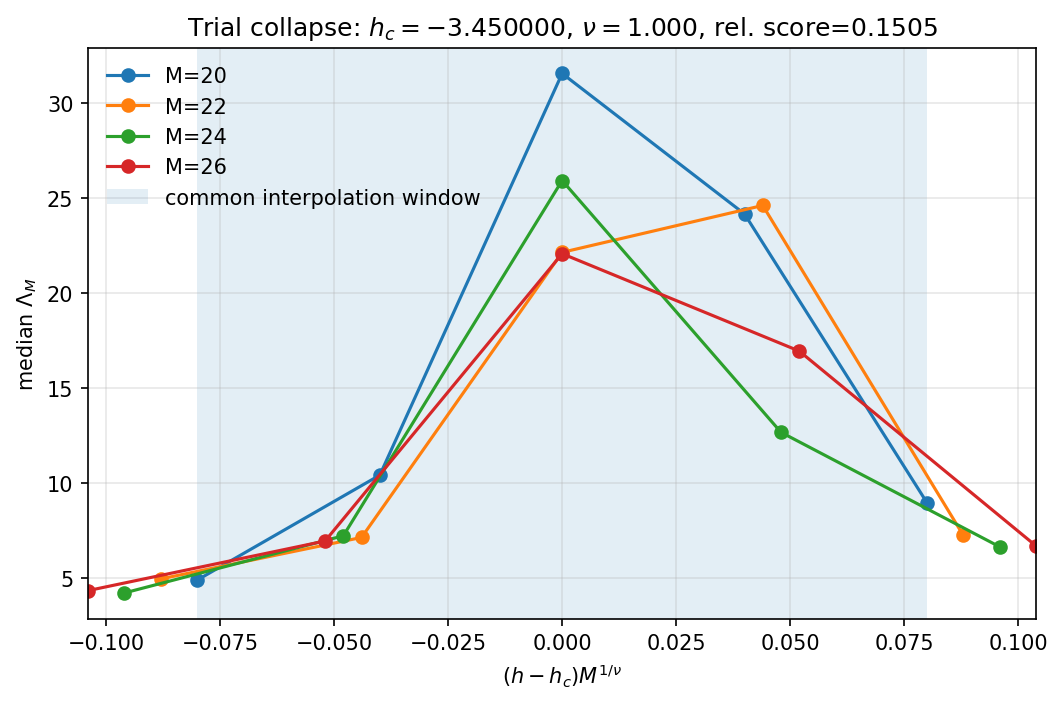

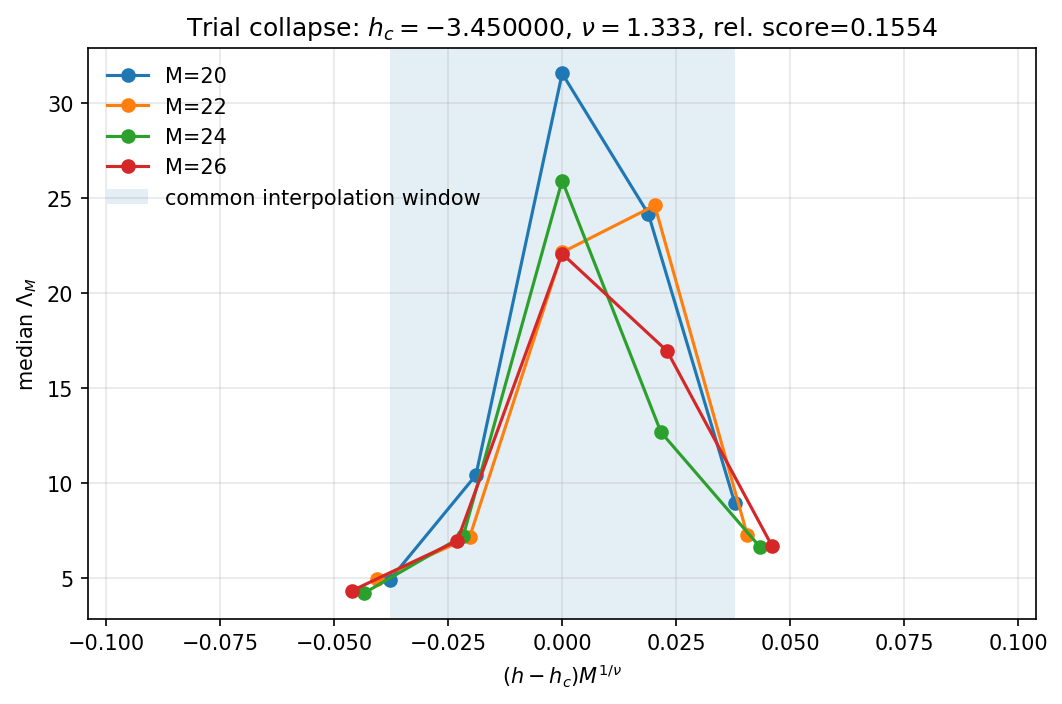

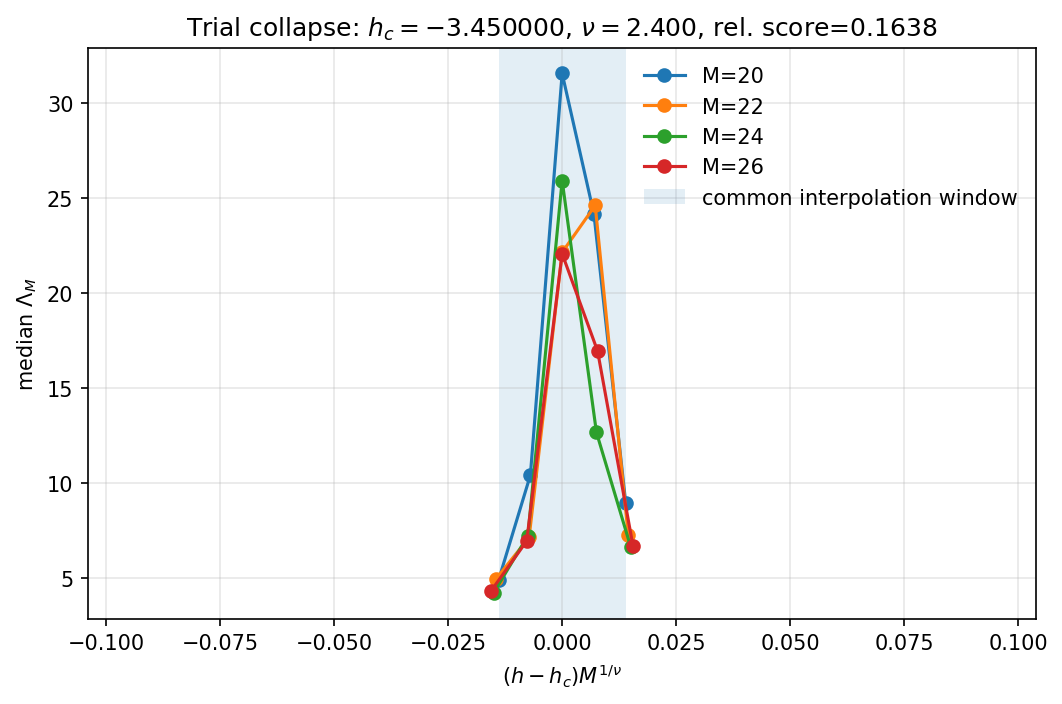

,nu,hc,score_abs,score_rel,xmin_overlap,xmax_overlap,note
0,1.000000,-3.45,2.549643,0.150481,-0.080000,0.080000,OK
1,1.333333,-3.45,2.604153,0.155447,-0.037830,0.037830,OK
2,2.400000,-3.45,2.700843,0.163783,-0.013937,0.013937,OK


In [7]:
# ============================================================
# Improved trial-collapse diagnostics
# Compare nu = 1, 4/3, 2.4 more quantitatively
# ============================================================

def get_scaled_curves(summary, hc=-3.450, nu=1.0, use_median=True):
    """
    Return scaled curves:
        x = (h - hc) M^{1/nu}
        y = Lambda_M

    Output: dict[M] = (x_sorted, y_sorted)
    """
    ycol = "median_Lambda" if use_median else "mean_Lambda"

    curves = {}

    for M, ss in summary.groupby("M"):
        ss = ss.sort_values("h")

        x = (ss["h"].values - hc) * (float(M) ** (1.0 / nu))
        y = ss[ycol].values

        order = np.argsort(x)
        curves[int(M)] = (x[order], y[order])

    return curves


def collapse_quality_score(summary, hc=-3.450, nu=1.0, use_median=True, n_grid=200):
    """
    Compute a simple collapse quality score.

    Procedure:
    1. For each M, compute x=(h-hc)M^{1/nu}.
    2. Find the common x-overlap shared by all M.
    3. Interpolate all curves onto the same x-grid.
    4. Compute RMS spread around the mean curve.

    Smaller score means better collapse.

    This is only a diagnostic, not a final statistical fit.
    """
    curves = get_scaled_curves(summary, hc=hc, nu=nu, use_median=use_median)

    # common overlap region
    xmin = max(np.min(x) for x, y in curves.values())
    xmax = min(np.max(x) for x, y in curves.values())

    if xmin >= xmax:
        return {
            "nu": nu,
            "hc": hc,
            "score_abs": np.nan,
            "score_rel": np.nan,
            "xmin_overlap": xmin,
            "xmax_overlap": xmax,
            "note": "No common x-overlap",
        }

    xgrid = np.linspace(xmin, xmax, n_grid)

    y_interp_list = []

    for M, (x, y) in curves.items():
        y_interp = np.interp(xgrid, x, y)
        y_interp_list.append(y_interp)

    Y = np.vstack(y_interp_list)

    mean_curve = np.mean(Y, axis=0)
    spread = Y - mean_curve[None, :]

    score_abs = np.sqrt(np.mean(spread**2))

    # relative score normalized by typical signal size
    denom = np.sqrt(np.mean(mean_curve**2))
    score_rel = score_abs / denom if denom > 0 else np.nan

    return {
        "nu": nu,
        "hc": hc,
        "score_abs": score_abs,
        "score_rel": score_rel,
        "xmin_overlap": xmin,
        "xmax_overlap": xmax,
        "note": "OK",
    }


def plot_trial_collapse_improved(
    summary,
    hc=-3.450,
    nu=1.0,
    use_median=True,
    fixed_xlim=None,
    show_overlap=True,
):
    """
    Improved collapse plot.

    fixed_xlim:
        If provided, use the same xlim for different nu.
        Example: fixed_xlim=(-0.12, 0.12)

    show_overlap:
        Highlight the common x-overlap used in quality-score calculation.
    """
    curves = get_scaled_curves(summary, hc=hc, nu=nu, use_median=use_median)

    score = collapse_quality_score(
        summary,
        hc=hc,
        nu=nu,
        use_median=use_median,
    )

    y_label = r"median $\Lambda_M$" if use_median else r"mean $\Lambda_M$"

    plt.figure(figsize=(7.2, 4.8), dpi=150)

    for M, (x, y) in curves.items():
        plt.plot(
            x,
            y,
            marker="o",
            linewidth=1.5,
            label=f"M={M}",
        )

    if show_overlap and score["note"] == "OK":
        plt.axvspan(
            score["xmin_overlap"],
            score["xmax_overlap"],
            alpha=0.12,
            label="common interpolation window",
        )

    plt.xlabel(r"$(h-h_c)M^{1/\nu}$")
    plt.ylabel(y_label)

    plt.title(
        rf"Trial collapse: $h_c={hc:.6f}$, "
        rf"$\nu={nu:.3f}$, "
        rf"rel. score={score['score_rel']:.4f}"
    )

    if fixed_xlim is not None:
        plt.xlim(*fixed_xlim)

    plt.grid(alpha=0.3)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    return score


def compare_trial_collapses(
    summary,
    hc=-3.450,
    nu_list=(1.0, 4/3, 2.4),
    use_median=True,
):
    """
    Plot trial collapses and print a score table.
    """
    score_rows = []

    # First determine a global xlim so the plots are not visually misleading.
    all_x = []

    for nu in nu_list:
        curves = get_scaled_curves(summary, hc=hc, nu=nu, use_median=use_median)
        for x, y in curves.values():
            all_x.extend(list(x))

    all_x = np.array(all_x)
    fixed_xlim = (np.min(all_x), np.max(all_x))

    for nu in nu_list:
        score = plot_trial_collapse_improved(
            summary,
            hc=hc,
            nu=nu,
            use_median=use_median,
            fixed_xlim=fixed_xlim,
            show_overlap=True,
        )
        score_rows.append(score)

    score_df = pd.DataFrame(score_rows)
    score_df = score_df.sort_values("score_rel")

    display(score_df)

    return score_df


# ============================================================
# Run improved comparison
# ============================================================

nu_clean_dirac = 1.0
nu_percolation = 4 / 3
nu_iqh_like = 2.4

score_df = compare_trial_collapses(
    summary_all,
    hc=-3.450,
    nu_list=(nu_clean_dirac, nu_percolation, nu_iqh_like),
    use_median=True,
)